### Astrophysical Analysis and Data Interpolation Summary

In this project, fundamental astrophysical calculations and professional observation planning workflows were executed using the **Astropy** and **Astroplan** libraries. Initially, the gravitational force between a star and an exoplanet system ($F = G \frac{m_1 m_2}{r^2}$) was computed in Newtons while maintaining physical unit consistency using `astropy.units`. Subsequently, by defining the coordinates of the Subaru Observatory and the celestial coordinates (`SkyCoord`) of Fomalhaut, a time-dependent airmass curve was generated to analyze the optimal observation window.

In the second part, 2D spatial grid generation and continuous numerical interpolation were implemented using **SciPy** (`RegularGridInterpolator`). Overall, this work demonstrates a unified Python pipeline that seamlessly integrates astrophysical data analysis, observational target tracking, and multi-dimensional spatial modeling.

In [1]:
import astropy.constants as c
import astropy.units as u

# Define masses and distance
m_star = 3 * c.M_sun
m_planet = 10 * c.M_jup
distance = 2 * u.au

# Calculate gravitational force: F = G * m1 * m2 / r^2
F = c.G * m_star * m_planet / distance**2

print("Raw result:", F)
print("Force in Newtons:", F.to(u.N))

Raw result: 1.889285600523636e+48 m3 kg / (AU2 s2)
Force in Newtons: 8.442028042547203e+25 N


In [4]:
#pip install astroplan

In [6]:
# Required package: pip install astroplan
from astroplan import Observer
from astropy.coordinates import EarthLocation, SkyCoord

# Fetch target sky coordinates and observer location
fomalhaut = SkyCoord.from_name("Fomalhaut")
subaru = Observer.at_site("Subaru", timezone="US/Hawaii")
subaru_loc = subaru.location

print(f"Sky Coords of Fomalhaut: {fomalhaut}")
print(f"Geocentric Coords of Subaru: {subaru_loc}")

Sky Coords of Fomalhaut: <SkyCoord (ICRS): (ra, dec) in deg
    (344.41269272, -29.62223703)>
Geocentric Coords of Subaru: (-5464468.109716696, -2493053.6504484504, 2150943.6050810195) m


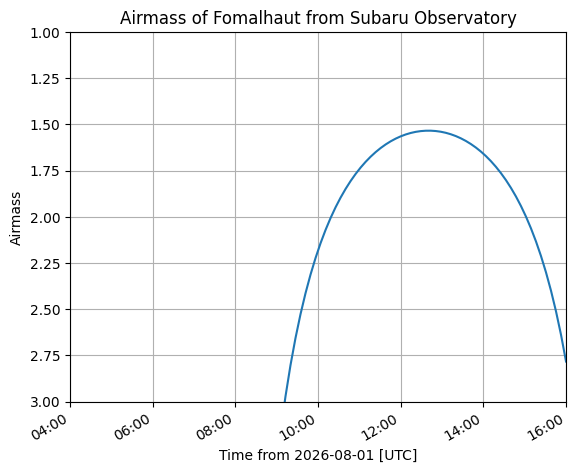

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from astroplan import FixedTarget, Observer
from astroplan.plots import plot_airmass
import astropy.units as u
from astropy.time import Time, TimeDelta

# Observer ve Target tanımı
subaru = Observer.at_site("Subaru")
target = FixedTarget.from_name("Fomalhaut")

# Hawaii için gece yarısına denk gelen UTC saati (UTC 10:00 = Hawaii 00:00)
time = Time("2026-08-01 10:00:00")

# TimeDelta ile birim uyarısını engelliyoruz
time_grid = time + TimeDelta(np.linspace(-6, 6, 100) * u.hour)

# Grafik çizimi
plot_airmass(target, subaru, time_grid)
plt.title("Airmass of Fomalhaut from Subaru Observatory")
plt.grid(True)
plt.show()

In [9]:
import numpy as np
from scipy.interpolate import RegularGridInterpolator

# 1. Define original 2D grid and scalar field z = sin(x) + cos(y)
x = np.linspace(0, 5, 6)
y = np.linspace(0, 5, 6)
X, Y = np.meshgrid(x, y, indexing="ij")
z = np.sin(X) + np.cos(Y)

# 2. Instantiate 2D grid interpolator
interp_2d = RegularGridInterpolator((x, y), z)

# 3. Query new coordinate points
new_points = np.array([[1.5, 2.5], [3.2, 4.1]])
interpolated_values = interp_2d(new_points)

print("Interpolated 2D Values:", interpolated_values)

Interpolated 2D Values: [ 0.17231454 -0.59837753]
